In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time
import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
print(GIT_REPO)
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()

CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


In [2]:
print(GIT_REPO)


/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis


# Load ntuples

In [21]:
limitTrees =OrderedDict()
dataCards = OrderedDict()
limits = OrderedDict()
ctaus = np.array([1,3,5,10,30,50,100,300,500,1000,1500,2000,3000,5000,8000,10000,30000,50000,100000])
mass = [15]
decays = ['B','D','Tau']
### limit branch: 2.5, 16.0, 50.0, 84.0, 97.5, obs
expected = ['0.025', '0.160','0.500','0.840','0.975']
CMSSW_BASE = "/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/"

categories = {
    'run 3':CMSSW_BASE+"/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3Comb/combine/v18/",
    'run2+run3':CMSSW_BASE+"/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run23Comb/combine/v18/",
}

# categories = {
#     'highMET':CMSSW_BASE+"/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3MET/limits_v12/",
#     # 'highMET_old':CMSSW_BASE+"/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3MET/limits_v9/",
#     'lowMET':CMSSW_BASE+"/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/combine/v18/",
#     # 'lowMET_old':CMSSW_BASE+"/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/combine/v15/",
#     'combined':CMSSW_BASE+"/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3Comb/combine/v18/",
# }
for cat, cardDir in categories.items():
    treeDir = cardDir.replace("datacards","limitTrees")
    if 'high' in cat: treeDir += "/combine/"
    limitTrees[cat] = {}
    dataCards[cat] = {}
    for decay in decays:
        for m in mass:
            if decay == 'B' and m < 15:continue
            if decay == 'Tau' and m < 7:continue
            key = f"ggH_HToSS_STo4{decay}_ms{m}"
            limitTrees[cat][key] = {}
            dataCards[cat][key] = {}

            for ct in ctaus:
                if 'high' in cat: 
                    cardTempDir = f'{cardDir}/ggH_Hto2Sto4{decay}_MH-125-MS-{m}/All/'
                    
                    card_name = f'combined_{ct}.0'
                else:
                    cardTempDir = cardDir
                    card_name = f'ggH_HToSS_STo4{decay}_ms{m}_ctau{ct}'
                dataCards[cat][key][ct] = f'{cardTempDir}/{card_name}.txt'
                
                treeTempDir = cardTempDir.replace("datacards","limitTrees")
                limitTrees[cat][key][ct] = f'{treeTempDir}/higgsCombine.{card_name}.AsymptoticLimits.mH120.root'
                # print(dataCards[cat][key][ct] )

                
                
                
    limits[cat] = {}
    for i,m in enumerate(limitTrees[cat].keys()):
        limits[cat][m] = np.ones((len(ctaus), 5))*1000000
        for j, k in enumerate(limitTrees[cat][m].keys()):

            if not os.path.isfile(limitTrees[cat][m][k]):
                print(limitTrees[cat][m][k])
                continue
            if not os.path.isfile(dataCards[cat][m][k]):
                print(dataCards[cat][m][k])
                continue
            line = open(dataCards[cat][m][k], "r").readline()
            if not line[0] == '#' :continue
            if "=" in line:signal_norm = float(line.split("=")[-1])
            else:signal_norm = float(line.split(" ")[3])
            # print(signal_norm, dataCards[cat][m][k])
            if signal_norm == 0:continue

            if len(uproot.open(limitTrees[cat][m][k]).keys()) == 2:
                T = uproot.open(limitTrees[cat][m][k])['limit']                
                if len(np.array(T['limit'].array())>0):limits[cat][m][j] = np.array(T['limit'].array())/signal_norm
        limits[cat][m] = np.array(limits[cat][m])
    print(ctaus)

/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4//src/HiggsAnalysis/MuonSystemLimit/combine/limitTrees_run3Comb/combine/v18//higgsCombine.ggH_HToSS_STo4Tau_ms15_ctau1.AsymptoticLimits.mH120.root
/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4//src/HiggsAnalysis/MuonSystemLimit/combine/limitTrees_run3Comb/combine/v18//higgsCombine.ggH_HToSS_STo4Tau_ms15_ctau3.AsymptoticLimits.mH120.root
/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4//src/HiggsAnalysis/MuonSystemLimit/combine/limitTrees_run3Comb/combine/v18//higgsCombine.ggH_HToSS_STo4Tau_ms15_ctau5.AsymptoticLimits.mH120.root
/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4//src/HiggsAnalysis/MuonSystemLimit/combine/limitTrees_run3Comb/combine/v18//higgsCombine.ggH_HToSS_STo4Tau_ms15_ctau10.AsymptoticLimits.mH120.root
/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4//src/HiggsAnalysis/MuonSystemLimit/combine/limitTrees_run3Comb/co

# load other limits

In [29]:
file_dir = '/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/data/limits_others/'


# ms_40 = file_dir + 'atlas_mh125_mx40_ms.csv'
# ms_15 = file_dir + 'atlas_mh125_mx15_ms.csv'
# ms_8 = file_dir + 'atlas_mh125_mx8_ms.csv'


other_limits = {}

# other_limits['EXO-21-008_csccsc'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_CSCCSC.csv' , delimiter=',')
# other_limits['EXO-21-008_cscdt'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_DTCSC.csv', delimiter=',')
# other_limits['EXO-21-008_dtdt'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_DTDT.csv', delimiter=',')
# other_limits['EXO-21-008_2tag'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_2tag_combined.csv', delimiter=',')

# other_limits['EXO-21-008_all'] = np.genfromtxt(file_dir + 'limitsbbbb_m15_hybridNew.txt', delimiter='\t')
# other_limits['atlas_2tag_15'] = np.genfromtxt(file_dir + 'atlas_2tag_15.csv', delimiter=',')

other_limits['EXO-21-008 (combined)'] = np.genfromtxt(file_dir + 'EXO-21-008-BB_15_all.csv', delimiter='\t')


# plot expected limit 

In [30]:
showOthers = 1

ggH_HToSS_STo4B_ms15
ggH_HToSS_STo4B_ms15 0.0008623065814450419 [0.00096622]
[9.19131067e+00 6.06057477e-01 2.05745336e-02 1.21445671e-03
 8.62306581e-04 9.66215855e-04 1.44735123e-03 1.93798889e-03
 3.22191548e-03 6.93736127e-03 1.53333079e-02 2.46596088e-02
 1.94058966e-01 5.24649145e-01 1.67079838e+00]
ggH_HToSS_STo4B_ms15
ggH_HToSS_STo4B_ms15 0.00039978304636317693 [0.00045549]
[0.13885417 0.01981245 0.0033268  0.00053743 0.00039978 0.00045549
 0.00062334 0.00078598 0.00113935 0.00187186 0.00295652 0.00366638
 0.00916807 0.0135592  0.03592847]
run 3_ggH_HToSS_STo4B_ms15
run2+run3_ggH_HToSS_STo4B_ms15
EXO-21-008 (combined) 0.0005976325409574583
True
170 fb^{-1} (13.6 TeV)


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/limits/run2+run3_ggH_HToSS_STo4B_ms15_expected_comparerun23.pdf has been created
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/limits/run2+run3_ggH_HToSS_STo4B_ms15_expected_comparerun23.png has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/limits/run2+run3_ggH_HToSS_STo4B_ms15_expected_comparerun23.C has been generated


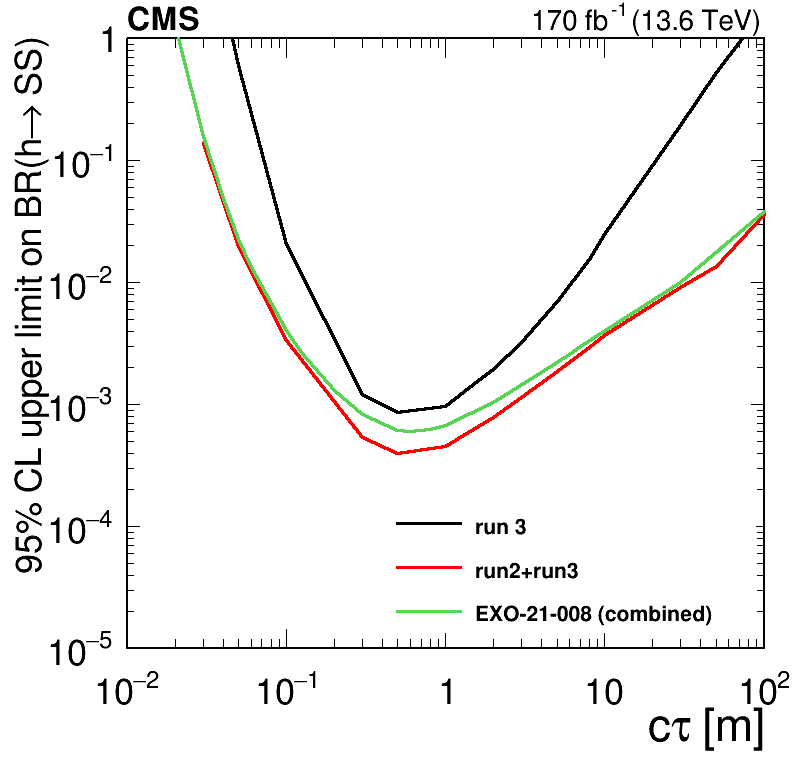

In [31]:
import os
import importlib
importlib.reload(sys.modules['CMS_lumi'])

opac_1sig = 0.25
opac_2sig = 0.1

ctaus_m = ctaus/1000


for m in limits[list(categories.keys())[0]].keys():
    if not "B" in m:continue
    leg = rt.TLegend(0.48,0.18,0.95,0.35)
    leg2 = rt.TLegend(0.18,0.20,0.40,0.33)
    leg.SetTextSize(0.03)
    leg.SetBorderSize(0)
    leg.SetEntrySeparation(0.01)
    leg2.SetTextSize(0.032)
    leg2.SetBorderSize(0)
    leg2.SetEntrySeparation(0.01)


    c = rt.TCanvas('c','c', 800, 800)
    c.SetRightMargin(0.04)

    rt.gStyle.SetOptFit(1011)
    h = {}
    h_exp1sig = {}
    h_exp2sig = {}
    h_obs = {}
    h_others = {}
    h_others_obs = {}
    h_others_1sig = {}
    for i, cat in enumerate(categories.keys()):
    
    
        print(m)
        if m not in limits[cat].keys():continue
        cond = limits[cat][m][:,2] < 1000000
        
        key = f"{cat}_{m}"
        if 'high' in key: 
            h[key] = create_TGraph(ctaus_m[cond], limits[cat][m][:,2][cond],  axis_title=['c#tau [m]', '95% CL upper limit on BR(h#rightarrow SS)'])
            h_exp1sig[key] = create_TGraph(np.hstack((ctaus_m[cond], np.flip(ctaus_m[cond]))), np.hstack((limits[cat][m][:,1][cond], np.flip(limits[cat][m][:,3][cond]))))
        elif 'low' in key:
            h[key] = create_TGraph(ctaus_m[cond], limits[cat][m][:,2][cond],  axis_title=['c#tau [m]', '95% CL upper limit on BR(h#rightarrow SS)'])
            h_exp1sig[key] = create_TGraph(np.hstack((ctaus_m[cond], np.flip(ctaus_m[cond]))), np.hstack((limits[cat][m][:,1][cond], np.flip(limits[cat][m][:,3][cond]))))
        else:
            h[key] = create_TGraph(ctaus_m[cond], limits[cat][m][:,2][cond],  axis_title=['c#tau [m]', '95% CL upper limit on BR(h#rightarrow SS)'])
            h_exp1sig[key] = create_TGraph(np.hstack((ctaus_m[cond], np.flip(ctaus_m[cond]))), np.hstack((limits[cat][m][:,1][cond], np.flip(limits[cat][m][:,3][cond]))))

        # h_exp1sig[key] = create_TGraph(np.hstack((ctaus_m[cond], np.flip(ctaus_m[cond]))), np.hstack((limits[cat][m][:,1][cond], np.flip(limits[cat][m][:,3][cond]))))
        mass_str = m[m.find('ms')+2:].replace('p','.')
        print(m,np.min(limits[cat][m][:,2][cond]), limits[cat][m][:,2][cond][ctaus_m[cond]==1])
        if '15' in m:print(limits[cat][m][:,2][cond])
        leg.AddEntry(h[key], cat.replace('MET', ' MET'), "L")

        if not showOthers:leg.AddEntry(h_exp1sig[key], "#pm 1 #sigma Expected", 'F')

        h_exp1sig[key].SetFillColorAlpha(std_color_list[i],opac_1sig)
        h[key].SetLineColor(std_color_list[i])
        h[key].SetMarkerColor(std_color_list[i])

        h[key].SetLineWidth(3)

        h[key].SetLineStyle(1)
        if decay == 'd' or decay == 'B' or decay == 'Tau': h[key].GetXaxis().SetLimits(0.01,100.0)
        else: h[key].GetXaxis().SetLimits(0.0001,100.0)
        h[key].GetYaxis().SetRangeUser(1e-5,1)

        h[key].GetXaxis().SetTitleOffset(1)
        h[key].GetYaxis().SetTitleSize(0.05)
        h[key].GetYaxis().SetTitleOffset(1.5)
        
    for i,m in enumerate(h.keys()):
        h[m].Draw('LA' if i == 0 else 'Lsame')
        if not showOthers: h_exp1sig[m].Draw('Fsame')
        print(m)
    if showOthers:
        for i,k in enumerate(other_limits.keys()):
                if "atlas" in k:
                    h_others[k] = create_TGraph(other_limits[k][:,0],other_limits[k][:,1],  axis_title=['c#tau [m]', '95% CL Limit on BR'])
                else:
                    h_others[k] = create_TGraph(other_limits[k][:,0],other_limits[k][:,3],  axis_title=['c#tau [m]', '95% CL Limit on BR'])
                    h_others_obs[k] = create_TGraph(other_limits[k][:,0],other_limits[k][:,6],  axis_title=['c#tau [m]', '95% CL Limit on BR'])
                    h_others_1sig[k] = create_TGraph(np.hstack((other_limits[k][:,0], np.flip(other_limits[k][:,0]))),\
                                                 np.hstack((other_limits[k][:,2], np.flip(other_limits[k][:,4]))),  axis_title=['c#tau [m]', '95% CL Limit on BR'])
                    h_others_obs[k].SetLineWidth(3)
                    h_others_obs[k].SetLineColor(std_color_list[i])
                    h_others_1sig[k].SetFillColorAlpha(std_color_list[i], opac_1sig)
                leg.AddEntry(h_others[k], k, 'L')
                h_others[k].SetLineWidth(3)
                h_others[k].SetLineColor(std_color_list[i+3])
                h_others[k].SetMarkerColor(std_color_list[i+3])
                
                # if k in h_others_obs.keys():h_others_obs[k].Draw("Lsame")
                h_others[k].Draw('Lsame')
                # h_others_1sig[k].Draw('Fsame')
                print(k, np.min(other_limits[k][:,3]))

    tdrstyle.setTDRStyle()
    CMS_lumi.cmsText     = "CMS"
    iPos = 0
    CMS_lumi.writeExtraText = 0
    CMS_lumi.extraText   = "Preliminary"
    CMS_lumi.lumi_13p6TeV = '170 fb^{-1}'

    if( iPos==0 ): CMS_lumi.relPosX = 0.12
    # CMS_lumi.CMS_lumi(c, 4, 0)
    CMS_lumi.CMS_lumi(c, 5, iPos)


    if not showOthers:leg.SetNColumns(2)

    leg.Draw()
    #     leg2.Draw()
    c.SetLogy()
    c.SetLogx()
    c.SetTicky(1)
    c.SetTickx(1)


    latex = rt.TLatex()
    latex.SetTextSize(0.06)
    latex.SetTextFont(42)

    if decay == 'd': latex.DrawLatex(200,0.002,  "S #rightarrow d#bar{d}")
    elif decay == 'B': latex.DrawLatex(200,0.002, "S #rightarrow b#bar{b}")
    elif decay == 'Tau': latex.DrawLatex(200,0.002, "S #rightarrow #tau^{+}#tau^{-}")

    if showOthers: 
        c.SaveAs(GIT_REPO + f"/limits/{m}_expected_comparerun23.pdf")
        c.SaveAs(GIT_REPO + f"/limits/{m}_expected_comparerun23.png")
        c.SaveAs(GIT_REPO + f"/limits/{m}_expected_comparerun23.C")
    else:
        c.SaveAs(GIT_REPO + f"/limits/{m}_expected_compareMETCat.pdf")
        c.SaveAs(GIT_REPO + f"/limits/{m}_expected_compareMETCat.png")
        c.SaveAs(GIT_REPO + f"/limits/{m}_expected_compareMETCat.C")

    tdrstyle.setTDRStyle()
    c.Draw()

In [17]:
for ct in ctaus/1000:
    print(ct, h_others['EXO-21-008 (Run 2)'].Eval(ct)/h['run2+run3_ggH_HToSS_STo4D_ms15'].Eval(ct))
    # print(ct, 1h['run2+run3_ggH_HToSS_STo4D_ms15'].Eval(ct)/h_others['EXO-21-008 (Run 2)'].Eval(ct))

0.001 1605.397618092813
0.003 1390.1050783277065
0.005 1157.0639450178292
0.01 480.7530354187905
0.03 1.2028848036597943
0.05 1.1508349168163452
0.1 1.2320484423298417
0.3 1.784220234148284
0.5 1.8691448758241882
1.0 1.8785481295927577
1.5 1.658651100311622
2.0 1.6191756425849624
3.0 1.5386236853095803
5.0 1.4201328449496753
8.0 1.2932326554719322
10.0 1.2317644031679489
30.0 1.1857792490067856
50.0 1.6337050083908278
100.0 1.1920131419028823
